Jeanne THOMAS, Adrien MIGLIORE

#  Système de proies-prédateurs de Lotka-Volterra

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#syteme d'equation de Lotka-Volterra
def lotka(variable,a,b,c,d):
    
    x,y = variable
    
    return np.array([a*x-b*x*y, -c*y+d*x*y]) 

## Conditions initiales

In [5]:
pas = 0.001
t_max = 100

#taux de croissances des proies et des predateurs
#notés par la suite *param_lotka
a = 1.5
b = 0.2
c = 0.8
d = 0.1

# Point d'équilibre
x_eq = c / d
y_eq = a / b

# Conditions initiales multiples autour du point d'équilibre
conditions_initiales = [ (x_eq * 0.5, y_eq * 0.5), (x_eq * 1.2, y_eq * 0.8), (x_eq * 0.9, y_eq * 1.5), 
                        (x_eq * 1.1, y_eq * 1.1), (x_eq * 0.7, y_eq * 1.3),]


## Euler explicite

In [6]:
#estime la solution d’une EDO en évaluant la dérivée au début de chaque intervalle 
def euler_explicite(f, population_precedente, pas, *param_lotka):
    
    return population_precedente + pas*f(population_precedente, *param_lotka)

## Newton Raphson

In [7]:
#méthode itérative pour trouver les racines d’équations non linéaires
def newton_Raphson(F ,variable, delta=1e-6, max_iter=1000, tol = 1e-6):
    l1, l2 = variable.copy()
    iterations = 0
    F1 , F2 = F(l1, l2)
    
    while (np.linalg.norm(np.array([F1,F2]))>tol) and iterations < max_iter:
        F1 , F2 = F(l1, l2)
        F1_delta, F2_delta = F(l1 + delta, l2 + delta)

        derive_F1 = (F1_delta - F1) / delta
        l1 = l1 - F1 / derive_F1
        
        derive_F2 = ( F2_delta - F2)/ delta
        l2 = l2 - F2 / derive_F2
        
        iterations +=1
        
    if iterations > max_iter:
        raise ValueError("maximum d'itérations dépassé pour  les conditions : {}".format(variable))

    return np.array([l1, l2])

## Euler implicite

In [8]:
#estime la solution d’une EDO en évaluant la dérivée à la fin de l’intervalle
def euler_implicite(f, population_precedente, pas, *param_lotka):
    #système non linéaire de Newton Raphson
    def systeme_non_lineaire(l1, l2):
        
        population_suivante = np.array([l1, l2])
        F =  population_suivante - population_precedente - pas * f(population_suivante , *param_lotka)
        
        return F[0], F[1]
    
    return newton_Raphson(systeme_non_lineaire, population_precedente)


## Crank-Nicholson

In [9]:
#méthode implicite, estime la solution d’une EDO grâce à la moyenne entre les dérivées évaluées au début et à la fin du pas
def crank_nicholson(f, population_precedente, pas, *param_lotka):
    #système non linéaire de Newton Raphson
    def systeme_non_lineaire(l1, l2):
        
        population_suivante = np.array([l1, l2])
        F =  population_suivante - population_precedente - pas * 0.5 * (f(population_suivante , *param_lotka) + f(population_precedente, *param_lotka))
        
        return F[0], F[1]
    
    return newton_Raphson(systeme_non_lineaire, population_precedente)

## Heun 

In [10]:
#Runge-Kutta d’ordre 2, estime la solution d’une EDO en utilisant la moyenne de la pente initiale et de la pente estimée à la fin du pas 
def heun(f, population_precedente, pas, *param_lotka):
    
    population = population_precedente + pas * f(population_precedente, *param_lotka)
    
    return population_precedente + (pas / 2) * (f(population_precedente, *param_lotka) + f(population, *param_lotka)) 

## Runge kutta d'ordre 4

In [11]:
#méthode explicite qui estime la solution d'une EDO en approximant l'intégrale par une somme avec à l'intérieur des étapes intermédiares à effectuer pour obtenir chaque paramètre de la somme
def rk4(f, population_precedente, pas, *param_lotka):
    
    #k1 est la pente au début de l'intervalle ;
    k1 = f(population_precedente, *param_lotka)
    
    #k2 est la pente au milieu de l'intervalle, en utilisant la pente k1 pour calculer la valeur de y au point tn + h/2 par le biais de la méthode d'Euler ;
    k2 = f(population_precedente + pas * k1 / 2, *param_lotka)
    
    #k3 est de nouveau la pente au milieu de l'intervalle, mais obtenue cette fois en utilisant la pente k2 pour calculer y ;
    k3 = f(population_precedente + pas * k2 / 2, *param_lotka)
    
    #k4 est la pente à la fin de l'intervalle, avec la valeur de y calculée en utilisant k3.
    k4 = f(population_precedente + pas * k3, *param_lotka)
    
    return population_precedente + (pas / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

## Simulation

In [12]:
#simulation des algorithmes pour obtenir un tableau de données sur le nombre de proies et prédateurs dans les populations
def simulation(algorithme, x0, y0, a, b, c, d, pas, t_max):
    
    t = np.arange(0, t_max+pas, pas)
    population = np.zeros((len(t), 2))
    population[0] = np.array([x0, y0])

    for i in range(1, len(t)):
        # *param_lotka vaudra ici toujours a, b, c, d
        population[i] = algorithme(lotka, population[i-1], pas, a, b, c, d)

    return t, population


## Graphiques

Affichage du modèle de : euler_explicite


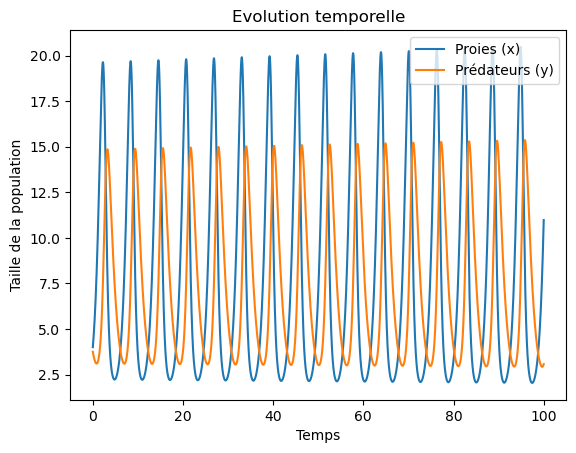

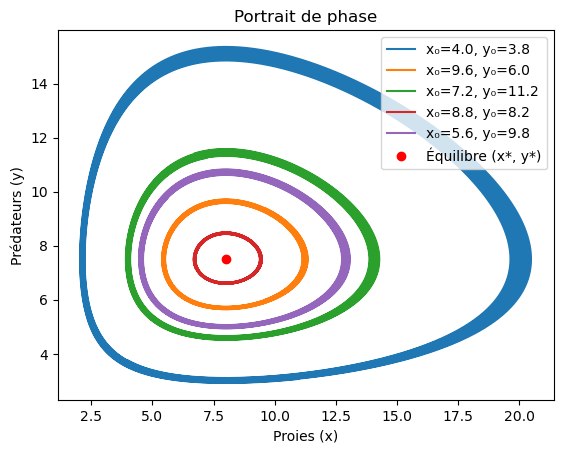

Affichage du modèle de : euler_implicite


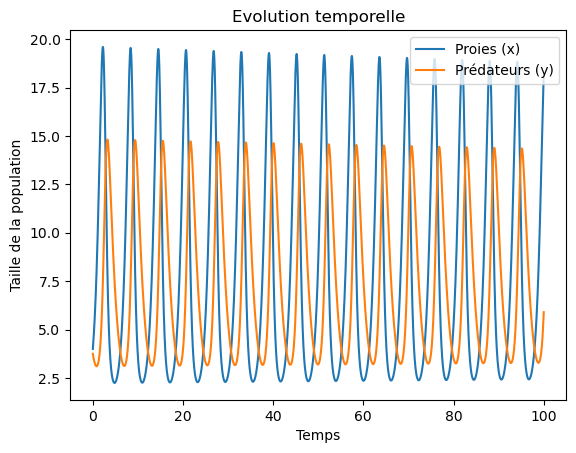

KeyboardInterrupt: 

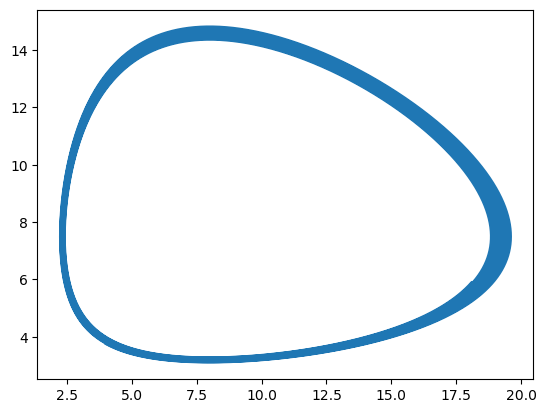

In [13]:
#affichage de la taille de la population des proies et des prédateurs en fonction du temps
def affichage_temporel(fonction, positions_de_depart):
    x0, y0 = positions_de_depart[0]
    t, population = simulation(fonction, x0, y0, a, b, c, d, pas, t_max)
    x = population[:, 0]
    y = population[:, 1]
    plt.plot(t, x, label="Proies (x)")
    plt.plot(t, y, label="Prédateurs (y)")
    plt.xlabel('Temps')
    plt.ylabel('Taille de la population')
    plt.title('Evolution temporelle')
    plt.legend()
    plt.show()

#affichage des portraits de phases des prédateurs en fonction des proies et affichage du point d'équilibre
def affichage_portrait_de_phase(fonction, positions_de_depart):
    for (x0, y0) in positions_de_depart:
        t, population = simulation(fonction, x0, y0, a, b, c, d, pas, t_max)
        x = population[:, 0]
        y = population[:, 1]
        plt.plot(x, y, label=f"x₀={x0:.1f}, y₀={y0:.1f}")

    # Ajout du point d'équilibre
    plt.plot(x_eq, y_eq, 'ro', label="Équilibre (x*, y*)")
    
    plt.xlabel("Proies (x)")
    plt.ylabel("Prédateurs (y)")
    plt.title("Portrait de phase")
    plt.legend()
    plt.show()


liste_fonctions=[euler_explicite, euler_implicite, crank_nicholson, heun, rk4]
for i in liste_fonctions:
    print("Affichage du modèle de :", i.__name__)
    affichage_temporel(i, conditions_initiales)
    affichage_portrait_de_phase(i, conditions_initiales)  


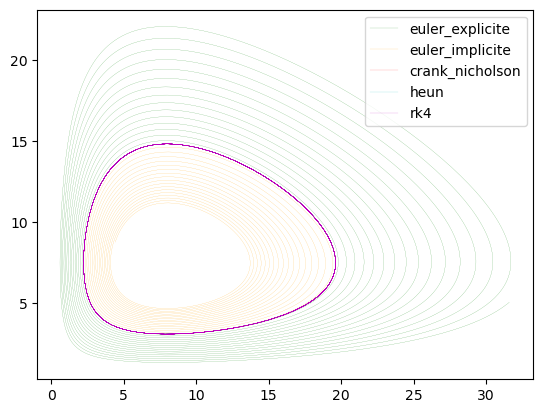

In [18]:
liste_fonctions=[euler_explicite, euler_implicite, crank_nicholson, heun, rk4]
pas = 0.01
t_max = 100
#pas = 0.2
#t_max = 500
#liste_fonctions = [crank_nicholson, heun, rk4]
liste_color = ['g', 'orange', 'r' ,'c', 'm']

def affichage_portrait_de_phase(methodes):
    x0, y0 = conditions_initiales[0]
    for i in range(len(methodes)):
        t, population = simulation(methodes[i], x0, y0, a, b, c, d, pas, t_max)
        x = population[:, 0]
        y = population[:, 1]
        plt.plot(x, y, label=methodes[i].__name__,linewidth=0.1, color=liste_color[i])
    plt.legend()
    plt.show()

affichage_portrait_de_phase(liste_fonctions)